# Nearest neighbourhood classifier

In one sentence, kNN looks for other objects in the neighborhood and assigns the most popular label to new objects. The $k$ in the name is the number of objects that we look for labels in the neighborhood.

In [4]:
!pip install tensorflow[and-cuda]

  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 2.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.1 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 1.0 MB/s eta 0:00:0000:0100:09m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 1.4 MB/s eta 0:00:00a 0:00:01


In [6]:
import numpy as np
import tensorflow_datasets as tfds
import pandas as pd
from math import sqrt
from sklearn.metrics import accuracy_score

# Construct a tf.data.Dataset
ds = tfds.load('titanic', split='train', shuffle_files=True)
titanic_df = tfds.as_dataframe(ds)

#titanic_df = pd.read_csv("titanic-train.csv")
titanic_df.drop("name", axis=1, inplace=True)
titanic_df.head()

columns = ['survived','age','fare']
features = columns[1:]
titanic_df = titanic_df[columns].replace([np.inf, -np.inf], np.nan).dropna()

titanic_df = titanic_df[titanic_df['fare'] > 30]

survivded_df = titanic_df[titanic_df['survived']==1].sample(50, random_state=12345)
not_survivded_df = titanic_df[titanic_df['survived']==0].sample(50, random_state=12345)

train_set = survivded_df.sample(40, random_state=12345)
train_set = pd.concat([train_set, not_survivded_df.sample(40, random_state=12345)])
plot_train_set = train_set
train_set_labels = train_set['survived']
train_set = train_set[features]


test_set = survivded_df.sample(10, random_state=12345)
test_set = pd.concat([test_set, not_survivded_df.sample(10, random_state=12345)])
plot_test_set = test_set
test_set_labels = test_set['survived']
test_set = test_set[features]

k = 5

def calculate_distance(x, v):
    """
    This method calculates the Euclidean distance between object x and v.

    :param x: first object
    :param v: second object
    :return: Euclidean distance
    """
    return sqrt((x[0] - v[0]) ** 2 + (x[1] - v[1]) ** 2)

def calculate_distance_matrix():
    """
    This method calculates the distance matrix between all objects.

    :return: A matrix of distances
    """    
    distance_matrix = np.zeros((len(data_set),len(data_set)))
    for i in range(len(data_set)):
        for j in range(len(data_set)):
            distance_matrix[i, j] = calculate_distance(data_set[i], data_set[j])
    return distance_matrix

def find_closest_objects(x, k):
    """
    Finds k closts objects to x.

    :return: A list of objects' ids.
    """        
    distances = []
    i = 0
    for item in train_set.values:
        distances.append([i, calculate_distance(x, item)])
        i = i + 1
    distances=np.array(distances)
    label_ids = distances[distances[:, 1].argsort()][:k,0]
    return [int(item) for item in label_ids]


def predict():
    """
    Assign a label of the most common label in the list of closest objects.

    :return: A list of predictions.
    """        
    predictions = []
    for item in test_set.values:
        label_ids = find_closest_objects(item, k)
        counts = np.bincount(train_set_labels.values[label_ids])
        label = np.argmax(counts)
        predictions.append(label)
    return predictions



predictions = predict()
acc = accuracy_score(predictions, test_set_labels)
print(acc)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/igor/tensorflow_datasets/titanic/incomplete.8YPEW8_4.0.0/titanic-train.tfrecord*...:   0%|    …

Dataset titanic downloaded and prepared to /home/igor/tensorflow_datasets/titanic/4.0.0. Subsequent calls will reuse this data.


E0000 00:00:1774132296.191972   24285 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1774132296.337621   27956 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


0.6


In [19]:
plot_train_set["color"] = plot_train_set["survived"].map({1: "green", 0: "red"})

In [20]:
plot_test_set['predicted'] = predictions

In [21]:
plot_test_set["color"] = "gray"

plot_test_set.loc[
    (plot_test_set["survived"] == 1) & (plot_test_set["predicted"] == 0),
    "color"
] = "green"

plot_test_set.loc[
    (plot_test_set["survived"] == 1) & (plot_test_set["predicted"] == 1),
    "color"
] = "blue"

plot_test_set.loc[
    (plot_test_set["survived"] == 0) & (plot_test_set["predicted"] == 0),
    "color"
] = "orange"

plot_test_set.loc[
    (plot_test_set["survived"] == 0) & (plot_test_set["predicted"] == 1),
    "color"
] = "purple"
plot_test_set = plot_test_set.drop(['predicted'], axis=1)

In [22]:
plot_set = pd.concat([plot_test_set, plot_train_set])

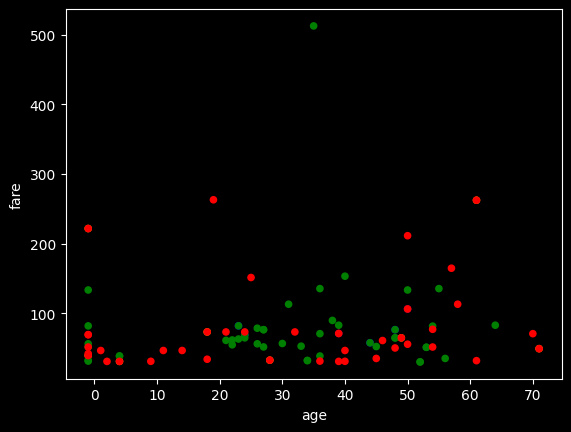

In [23]:
res = plot_set.plot.scatter(x='age', y='fare', c=plot_set['color']).get_figure()

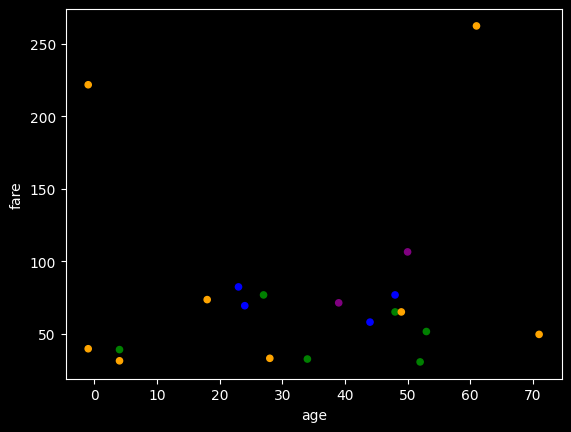

In [24]:
res = plot_test_set.plot.scatter(x='age', y='fare', c=plot_test_set['color']).get_figure()